# Exercise 2: Image Compression using K-Means Clustering

Compress an image by reducing the number of colors using K-Means clustering. Each pixel is replaced with its nearest cluster centroid.

In [1]:
# CH.SC.U4CSE24119 Kavin JS

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

## Generate a 396x396x3 RGB Image

Original image shape: (396, 396, 3)


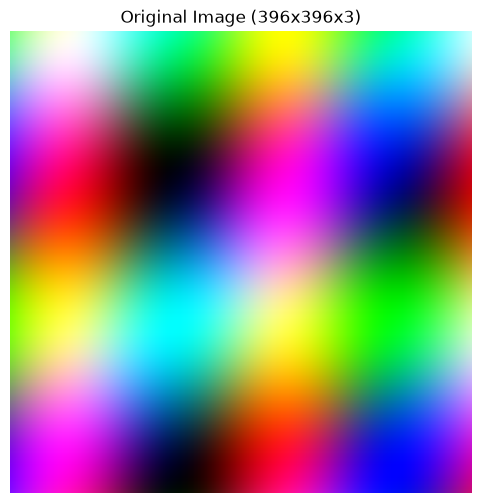

In [2]:
np.random.seed(42)
size = 396

# Create a gradient/blob pattern
y_coords, x_coords = np.mgrid[0:size, 0:size]
r = (np.sin(x_coords / 30.0) * 127 + 128).astype(np.uint8)
g = (np.cos(y_coords / 40.0) * 127 + 128).astype(np.uint8)
b = (np.sin((x_coords + y_coords) / 50.0) * 127 + 128).astype(np.uint8)

image = np.stack([r, g, b], axis=-1)
print(f'Original image shape: {image.shape}')

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title('Original Image (396x396x3)')
plt.axis('off')
plt.show()

## Reshape and Apply K-Means (k=16)

In [3]:
# Reshape to (n_pixels, 3)
pixel_data = image.reshape(-1, 3)
print(f'Pixel data shape: {pixel_data.shape}')

# Apply KMeans with 16 clusters
kmeans = KMeans(n_clusters=16, random_state=42, n_init=10)
kmeans.fit(pixel_data)

# Replace each pixel with its cluster centroid
compressed = kmeans.cluster_centers_[kmeans.labels_].astype(np.uint8)
compressed_image = compressed.reshape(image.shape)

print(f'Unique colors in original: {len(np.unique(pixel_data, axis=0))}')
print(f'Unique colors in compressed: {len(np.unique(compressed, axis=0))}')

Pixel data shape: (156816, 3)


Unique colors in original: 148821
Unique colors in compressed: 16


## Display Both Images

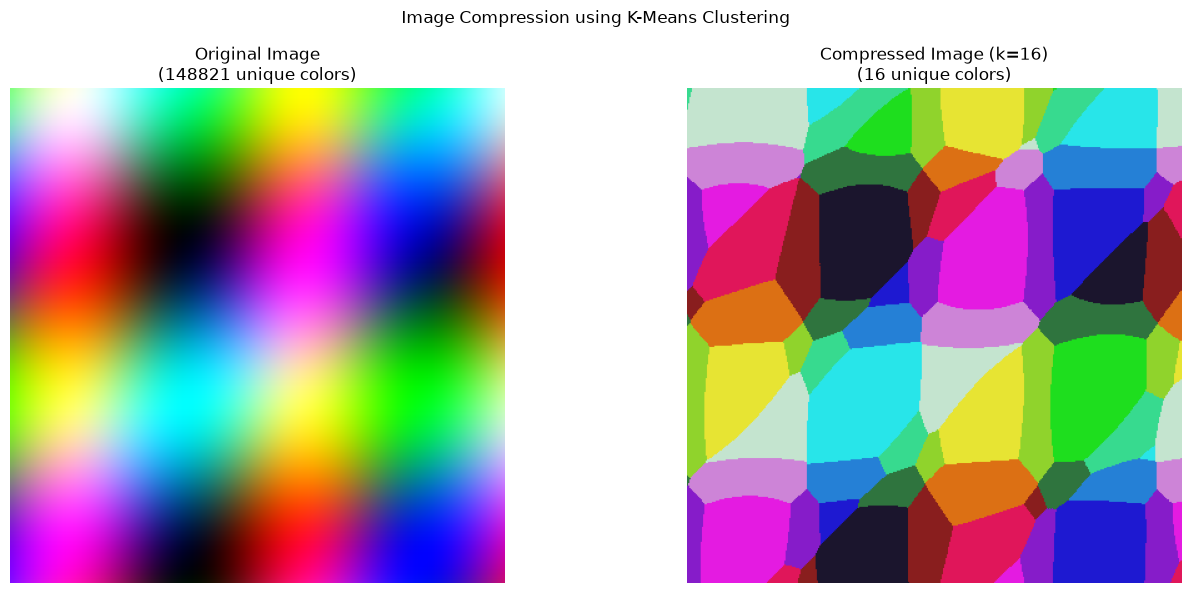

Saved kmeans_compressed.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(image)
axes[0].set_title(f'Original Image\n({len(np.unique(pixel_data, axis=0))} unique colors)')
axes[0].axis('off')

axes[1].imshow(compressed_image)
axes[1].set_title(f'Compressed Image (k=16)\n({len(np.unique(compressed, axis=0))} unique colors)')
axes[1].axis('off')

plt.suptitle('Image Compression using K-Means Clustering')
plt.tight_layout()
plt.show()

# Save the compressed image
plt.imsave('kmeans_compressed.png', compressed_image)
print('Saved kmeans_compressed.png')